# Customer Segmentation — 01-ml-project



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Repo-relative path, per SUBMISSION_CRITERIA.md:
# this notebook lives at submissions/<cohort>/<group-id>/01-ml-project/<group-id>_01-ml-project.ipynb
# so the dataset (checked into 01-ml-project/ at the repo root) is 4 levels up.
DATA_PATH = Path("../../../../01-ml-project/retail_transactions_segmentation.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Run this notebook from its required repository folder: "
        "submissions/<cohort>/<group-id>/01-ml-project/"
    )

df = pd.read_csv(DATA_PATH)
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

print("Dataset shape:", df.shape)
print("Unique customers:", df["customer_id"].nunique())


Dataset shape: (3663, 4)
Unique customers: 300


In [2]:
df.head(20)

,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports
5,5059,2024-06-11,885.21,Sports
6,5288,2024-11-17,318.49,Groceries
7,5073,2024-12-07,717.91,Sports
8,5073,2024-11-16,1506.36,Home & Living
9,5274,2024-09-13,235.12,Home & Living


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3663 entries, 0 to 3662
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       3663 non-null   int64         
 1   transaction_date  3663 non-null   datetime64[us]
 2   amount            3663 non-null   float64       
 3   product_category  3663 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 114.6 KB


In [4]:
df.describe()

,customer_id,transaction_date,amount
count,3663.000000,3663,3663.000000
mean,5147.309036,2024-07-22 09:56:45.405405,513.028376
min,5001.000000,2024-01-01 00:00:00,5.000000
25%,5073.000000,2024-05-04 00:00:00,276.550000
50%,5142.000000,2024-07-25 00:00:00,411.870000
75%,5223.000000,2024-10-11 00:00:00,767.740000
max,5300.000000,2024-12-30 00:00:00,1506.360000
std,85.189230,NaN,305.332100


In [5]:
df.duplicated().sum()

np.int64(0)

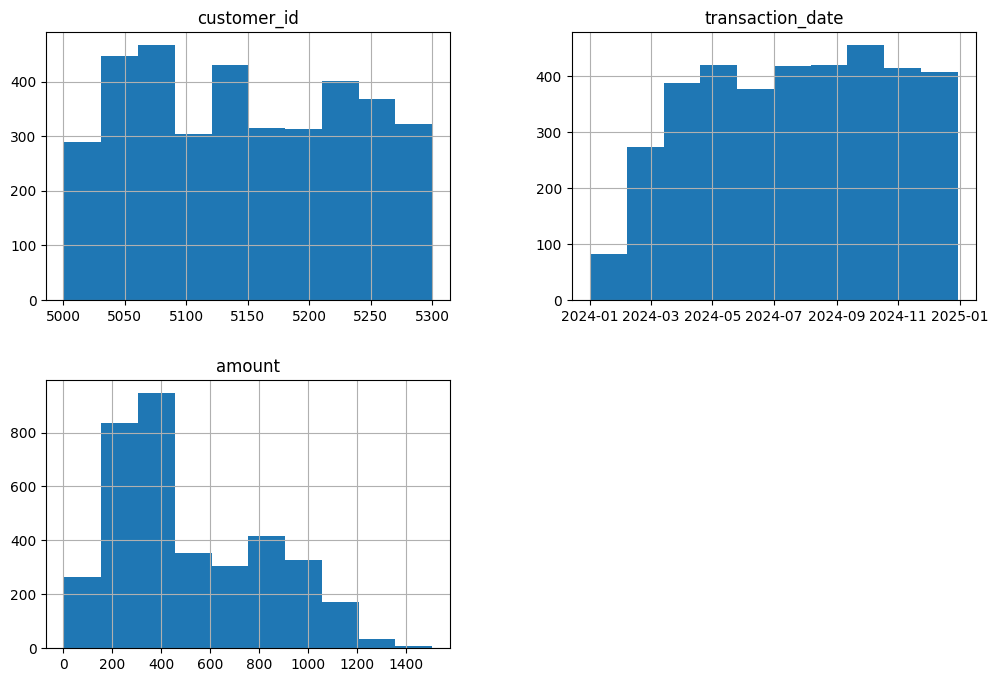

In [6]:
df.hist(figsize=(12,8))
plt.show()

In [7]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [8]:
df["product_category"].value_counts()

product_category
Groceries        640
Sports           630
Home & Living    611
Fashion          600
Electronics      591
Beauty           591
Name: count, dtype: int64

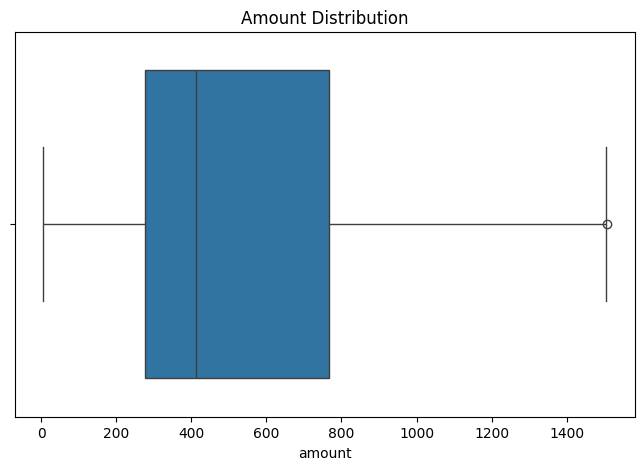

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["amount"])
plt.title("Amount Distribution")
plt.show()

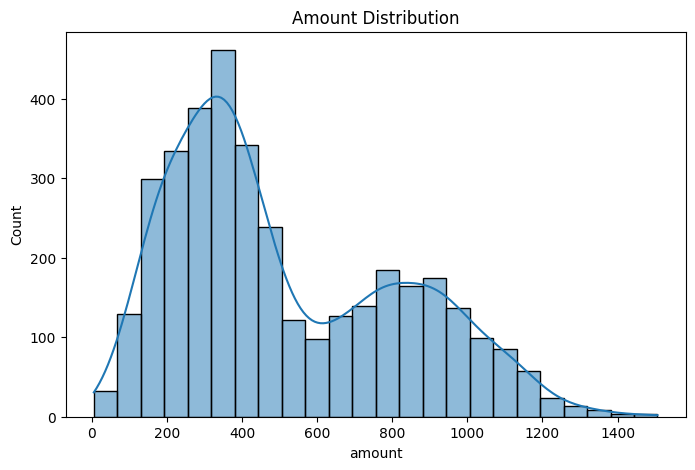

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["amount"], kde=True)
plt.title("Amount Distribution")
plt.show()

In [11]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)

print("Number of outliers:",
      ((df["amount"] < lower) | (df["amount"] > upper)).sum())

Q1: 276.54999999999995
Q3: 767.74
IQR: 491.19000000000005
Lower Bound: -460.2350000000001
Upper Bound: 1504.525
Number of outliers: 1


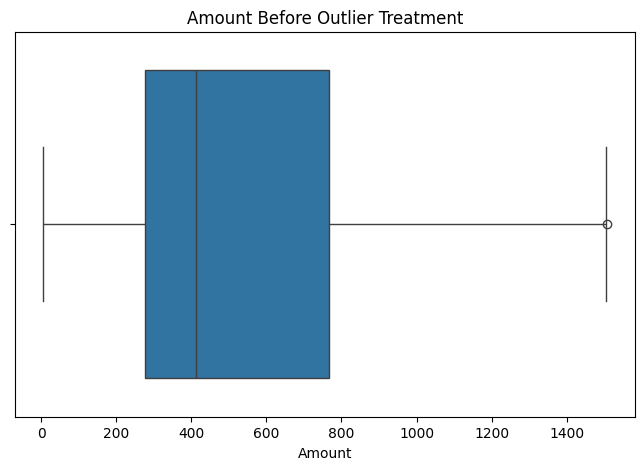

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["amount"])

plt.title("Amount Before Outlier Treatment")
plt.xlabel("Amount")

plt.show()

In [13]:
df[df["amount"] > 1504.525]

,customer_id,transaction_date,amount,product_category
8,5073,2024-11-16,1506.36,Home & Living


# The Six Required Submission Points

This notebook is organized exactly around the six required delivery criteria:

1. **Point 1 — RFM feature table built from the raw transactions**
2. **Point 2 — Features scaled before clustering**
3. **Point 3 — Choice of k justified with evidence**
4. **Point 4 — K-Means fitted with the chosen k**
5. **Point 5 — PCA visualization of the clusters**
6. **Point 6 — Named personas grounded in the numbers**

The original exploratory analysis is kept above as supporting EDA. The six labelled sections below are the required submission content.


## Point 1 — RFM feature table built from the raw transactions

The raw CSV contains **3,663 transaction-level rows**. I aggregate those transactions to a customer-level table with **one row per customer (300 rows)**.

Definitions used:
- **Reference date:** the dataset's maximum `transaction_date`.
- **Recency:** days between the reference date and each customer's most recent purchase.
- **Frequency:** number of transactions made by the customer.
- **Monetary:** **total spend** by the customer.

This satisfies the requirement to build RFM before clustering instead of clustering raw transaction rows.


In [14]:
reference_date = df["transaction_date"].max()

rfm = (
    df.groupby("customer_id")
      .agg(
          Recency=("transaction_date", lambda x: (reference_date - x.max()).days),
          Frequency=("transaction_date", "count"),
          Monetary=("amount", "sum")
      )
      .reset_index()
)

print("Reference date:", reference_date.date())
print("RFM shape:", rfm.shape)
display(rfm.head())

assert rfm.shape[0] == 300, "Expected 300 customers in the RFM table."
assert rfm["customer_id"].nunique() == 300, "customer_id should be unique in the RFM table."


Reference date: 2024-12-30
RFM shape: (300, 4)


,customer_id,Recency,Frequency,Monetary
0,5001,1,16,5172.45
1,5002,22,18,6158.98
2,5003,36,3,654.12
3,5004,4,35,31050.88
4,5005,25,16,5700.91


## Point 2 — Features scaled before clustering

The three RFM features are on different scales: Recency is measured in days, Frequency is a transaction count, and Monetary is a money value. I therefore standardize all three features before K-Means so that one feature does not dominate the distance calculation just because its numeric scale is larger.


In [15]:
from sklearn.preprocessing import StandardScaler

rfm_features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[rfm_features])

print("Scaled matrix shape:", X_scaled.shape)
print("Scaled means:", np.round(X_scaled.mean(axis=0), 4))
print("Scaled standard deviations:", np.round(X_scaled.std(axis=0), 4))


Scaled matrix shape: (300, 3)
Scaled means: [-0. -0.  0.]
Scaled standard deviations: [1. 1. 1.]


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

k_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(k_results)


,k,inertia,silhouette_score
0,2,394.208028,0.678910
1,3,183.032138,0.678170
2,4,93.388049,0.570227
3,5,71.407066,0.523155
4,6,50.343627,0.519382
5,7,41.125688,0.462554
6,8,30.223591,0.481482
7,9,24.119083,0.482195
8,10,21.074266,0.476483


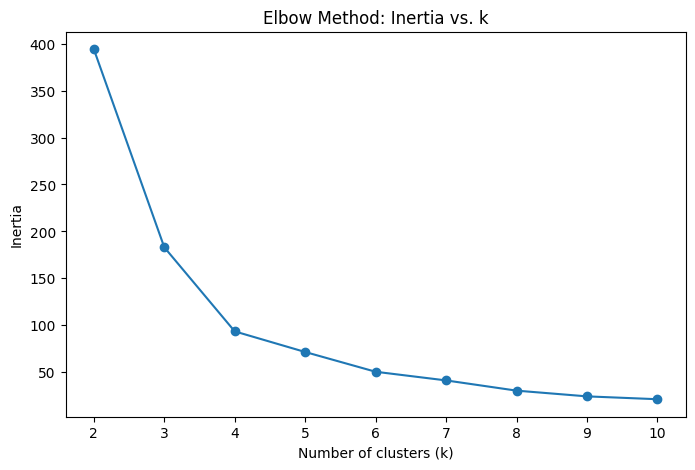

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method: Inertia vs. k")
plt.xticks(list(k_values))
plt.show()


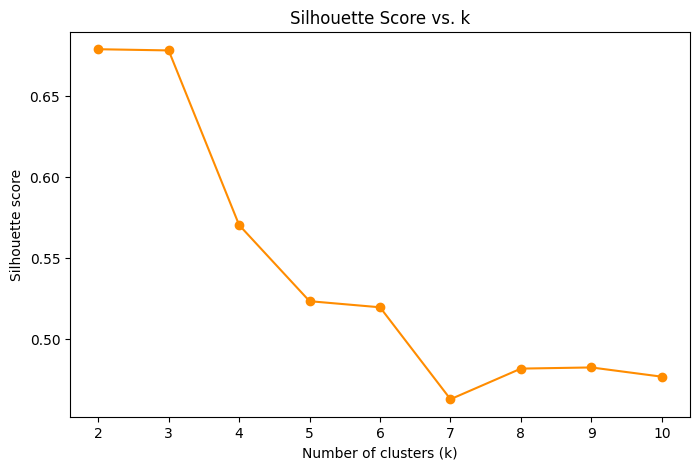

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["silhouette_score"], marker="o", color="darkorange")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs. k")
plt.xticks(list(k_values))
plt.show()


## Point 3 — Choice of k justified with evidence

### k selection reasoning

Looking at the table and both plots above (k = 2 to 10): the **silhouette score** is highest at k = 2–3 (~0.68), but those groupings are too coarse for the business goal because they do not separate customer value and engagement levels into enough actionable personas. The **elbow plot** shows a strong reduction in inertia up to around k = 4, after which the improvement becomes smaller. At k = 4, the silhouette score is still reasonably strong (~0.57). Therefore, **k = 4** is selected as a practical balance between cluster quality and business interpretability.


## Point 4 — K-Means fitted with the chosen k

I fit K-Means on the **scaled RFM features**, using the k justified above and `random_state=42` so that the result is reproducible. The resulting cluster label is then attached to every customer in the RFM table.


In [19]:
chosen_k = 4

kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

rfm["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
display(rfm["cluster"].value_counts().sort_index().rename("customers").to_frame())

display(rfm.head())


Cluster sizes:


,customers
cluster,
0,111
1,40
2,21
3,128


,customer_id,Recency,Frequency,Monetary,cluster
0,5001,1,16,5172.45,3
1,5002,22,18,6158.98,3
2,5003,36,3,654.12,0
3,5004,4,35,31050.88,1
4,5005,25,16,5700.91,3


## Point 5 — PCA visualization of the clusters

I reduce the three scaled RFM features to two principal components with PCA. The scatter plot uses the cluster label as the colour mapping and includes a title, axis labels, and legend so the segmentation is readable.


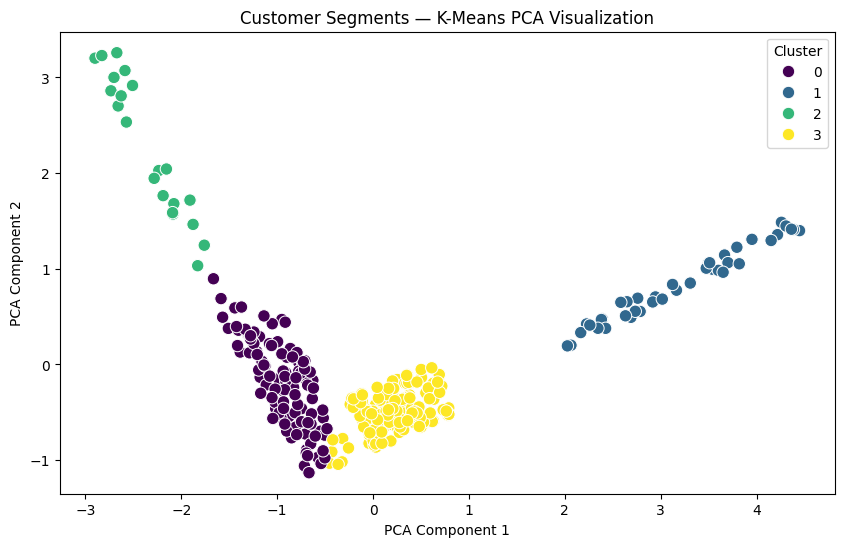

Explained variance ratio: [0.75  0.237]


In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

rfm["PCA1"] = X_pca[:, 0]
rfm["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm,
    x="PCA1",
    y="PCA2",
    hue="cluster",
    palette="viridis",
    s=80
)
plt.title("Customer Segments — K-Means PCA Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))


## Point 6 — Named personas grounded in the numbers

The table below shows the **mean Recency, Frequency, and Monetary value for every cluster**. These averages are the evidence used to assign business names.

Persona names must follow the RFM profile:
- lower Recency = more recent activity,
- higher Frequency = more repeat purchasing,
- higher Monetary = higher total spend.

Each persona below also includes an actionable business recommendation.


In [21]:
cluster_summary = (
    rfm.groupby("cluster")[rfm_features]
       .mean()
       .round(2)
)

cluster_summary["Customers"] = rfm["cluster"].value_counts().sort_index()
display(cluster_summary)


,Recency,Frequency,Monetary,Customers
cluster,,,,
0,70.57,4.23,752.49,111
1,7.40,35.00,29683.61,40
2,262.38,2.10,320.48,21
3,19.22,13.67,4700.17,128


In [22]:
# Rank clusters by their RFM profile.
# Higher Frequency and Monetary are better; lower Recency is better.
ranked = cluster_summary.copy()

ranked["activity_score"] = (
    ranked["Frequency"].rank(ascending=False, method="first")
    + ranked["Monetary"].rank(ascending=False, method="first")
    + ranked["Recency"].rank(ascending=True, method="first")
)

# Identify clusters using the actual RFM values.
vip_cluster = ranked["activity_score"].idxmin()

remaining = ranked.drop(index=vip_cluster)
at_risk_cluster = remaining["Recency"].idxmax()

remaining = remaining.drop(index=at_risk_cluster)

if len(remaining) >= 2:
    loyal_cluster = (
        remaining["Frequency"].rank(ascending=False, method="first")
        + remaining["Recency"].rank(ascending=True, method="first")
    ).idxmin()
    remaining = remaining.drop(index=loyal_cluster)
else:
    loyal_cluster = None

persona_map = {vip_cluster: "VIP / High-Value Customers",
               at_risk_cluster: "At-Risk Customers"}

if loyal_cluster is not None:
    persona_map[loyal_cluster] = "Loyal Active Customers"

for cluster_id in cluster_summary.index:
    if cluster_id not in persona_map:
        persona_map[cluster_id] = "Occasional / Developing Customers"

persona_table = cluster_summary.copy()
persona_table["Persona"] = persona_table.index.map(persona_map)

display(persona_table)


,Recency,Frequency,Monetary,Customers,Persona
cluster,,,,,
0,70.57,4.23,752.49,111,Occasional / Developing Customers
1,7.40,35.00,29683.61,40,VIP / High-Value Customers
2,262.38,2.10,320.48,21,At-Risk Customers
3,19.22,13.67,4700.17,128,Loyal Active Customers


## Final Business Profile

The four clusters are translated into customer personas using the actual RFM averages. The table below also shows each segment's share of the 300 customers, making the result easier to communicate to a business stakeholder.


In [ ]:
final_profile = persona_table.copy()
final_profile["Customer %"] = (final_profile["Customers"] / len(rfm) * 100).round(1)
final_profile = final_profile[["Persona", "Customers", "Customer %", "Recency", "Frequency", "Monetary"]]
final_profile = final_profile.sort_values("Monetary", ascending=False)
display(final_profile.reset_index(drop=True))


In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=final_profile, x="Persona", y="Customers")
plt.title("Customer Segment Size")
plt.xlabel("Customer Persona")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## Business Recommendations

- **VIP / High-Value Customers:** protect retention with loyalty rewards, personalized premium offers, and early access to products.
- **Loyal Active Customers:** increase repeat purchases with personalized recommendations, bundles, and loyalty incentives.
- **At-Risk Customers:** run targeted re-engagement campaigns, reminders, and relevant limited-time offers.
- **Occasional / Developing Customers:** encourage a second or third purchase with relevant promotions, recommendations, and simple loyalty incentives.

### Key takeaway

The segmentation turns transaction history into actionable customer groups. The most valuable segments should be protected, inactive customers should be re-engaged, and occasional customers should be encouraged toward more frequent purchasing.


## Submission Quality Check

The notebook now contains the complete ML workflow: customer-level RFM construction, feature scaling, evidence-based k selection, K-Means clustering, PCA visualization, numerical cluster profiling, customer personas, segment-size visualization, and business recommendations.

**Chosen model:** K-Means with `k=4`, `random_state=42`, and `n_init=10`.

**Important note:** k=2 and k=3 have slightly higher silhouette scores, but k=4 was selected because it provides more useful and actionable business segmentation while retaining a reasonable silhouette score (~0.57).


In [23]:
# 2–3 sentence business interpretation for every persona.
for cluster_id, row in persona_table.iterrows():
    print(f"### {row['Persona']}")

    if row["Persona"] == "VIP / High-Value Customers":
        print(
            f"This segment has the strongest overall RFM profile, with average Recency "
            f"{row['Recency']:.1f} days, Frequency {row['Frequency']:.1f}, and Monetary "
            f"{row['Monetary']:.2f}. The business should focus on retention, loyalty rewards, "
            "and personalized premium offers to protect this high-value relationship."
        )
    elif row["Persona"] == "Loyal Active Customers":
        print(
            f"These customers purchase relatively frequently and have relatively recent activity "
            f"(average Recency {row['Recency']:.1f} days and Frequency {row['Frequency']:.1f}). "
            "The business should encourage repeat purchases through personalized recommendations "
            "and loyalty incentives."
        )
    elif row["Persona"] == "At-Risk Customers":
        print(
            f"These customers have the highest average Recency among the remaining segments "
            f"({row['Recency']:.1f} days), indicating weaker recent engagement. The business "
            "should prioritize targeted re-engagement messages, reminders, and relevant offers."
        )
    else:
        print(
            f"This group has a less consistent purchasing pattern than the strongest segments, "
            f"with average Recency {row['Recency']:.1f} days, Frequency {row['Frequency']:.1f}, "
            f"and Monetary {row['Monetary']:.2f}. The business should use relevant promotions "
            "and recommendations to encourage more frequent purchases."
        )
    print()


### Occasional / Developing Customers
This group has a less consistent purchasing pattern than the strongest segments, with average Recency 70.6 days, Frequency 4.2, and Monetary 752.49. The business should use relevant promotions and recommendations to encourage more frequent purchases.

### VIP / High-Value Customers
This segment has the strongest overall RFM profile, with average Recency 7.4 days, Frequency 35.0, and Monetary 29683.61. The business should focus on retention, loyalty rewards, and personalized premium offers to protect this high-value relationship.

### At-Risk Customers
These customers have the highest average Recency among the remaining segments (262.4 days), indicating weaker recent engagement. The business should prioritize targeted re-engagement messages, reminders, and relevant offers.

### Loyal Active Customers
These customers purchase relatively frequently and have relatively recent activity (average Recency 19.2 days and Frequency 13.7). The business should 

## Final self-check before submission

Before committing, verify every item below:

- [x] **Point 1:** customer-level RFM table with 300 rows, reference date stated, Monetary definition stated, `.head()` and `.shape` shown.
- [x] **Point 2:** RFM features standardized before K-Means, with an explanation of why scaling is needed.
- [x] **Point 3:** both Elbow and Silhouette are plotted for `k=2..10`, with written reasoning for the selected `k`.
- [x] **Point 4:** K-Means uses the justified `k`, `random_state=42`, and cluster labels are attached to customers.
- [x] **Point 5:** PCA reduces the scaled features to two components and the scatter plot has title, axis labels, and a cluster legend.
- [x] **Point 6:** mean RFM values are shown for every cluster, every cluster has a business persona, and each persona has an actionable explanation.
- [x] **Business profile:** segment sizes and customer percentages are summarized in one table.
- [x] **Business recommendations:** each persona has a clear recommended action.
- [x] **Final submission note:** the chosen `k=4` is explicitly justified against the higher silhouette scores at k=2–3.
